# Análisis y representación por mapas de calor y boxplots de datos de Facebook Marketplace

Para comenzar con el análisis primero cargamos los datos con Pandas y mostramos una descripción general de los datos, y ya de una vez cargamos seaborn y matplotlib para mostrar después los datos con mapas de color y boxplots en figuras.

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Facebook_Marketplace_data.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

Antes de realizar algun análisis crearé una copia del dataframe sin las columnas vacias (Column1 a Column4) ya que no son importantes para el análisis, por los que las eliminare con el método *drop()* colocando como parametros los nombres de las columnas a eliminar y declarando el eje como 1 (*axis=1*) que significa columnas (GeeksforGeeks, 2025a):

In [38]:
df_clean = df.copy()
df_clean = df_clean.drop(["Column1", "Column2", "Column3", "Column4"], axis=1)

Y vemos el cambio al volver a mostrar la información de nuestra copia del dataframe

In [39]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   int64 
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 661.1+ KB
None


Viendo una parte de los datos con el método *head()*, puedo observar que no hay datos raros, si acaso es interesante como la columna **status_published** no se considera como un tipo de dato *datetime*

In [40]:
display(df_clean.head())

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


Por ende voy a convertir dicha columna a datetime en formato año/dia/mes/ hora:minuto:segundo (Pandas - Converting Date Column From Dd/Mm/Yy Hh:Mm:Ss To Yyyy-mm-dd Hh:Mm:Ss, 2018)

In [41]:
df_clean['status_published'] = pd.to_datetime(df_clean['status_published'], format="mixed", dayfirst=True)
print(df_clean.info())
display(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   status_id         7050 non-null   int64         
 1   status_type       7050 non-null   object        
 2   status_published  7050 non-null   datetime64[ns]
 3   num_reactions     7050 non-null   int64         
 4   num_comments      7050 non-null   int64         
 5   num_shares        7050 non-null   int64         
 6   num_likes         7050 non-null   int64         
 7   num_loves         7050 non-null   int64         
 8   num_wows          7050 non-null   int64         
 9   num_hahas         7050 non-null   int64         
 10  num_sads          7050 non-null   int64         
 11  num_angrys        7050 non-null   int64         
dtypes: datetime64[ns](1), int64(10), object(1)
memory usage: 661.1+ KB
None


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0
1,2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0
2,3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0
3,4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0
4,5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0


Para comparar las variables realizaré un *describe()* con el atributo *include = "all"* para obtener un informe estadístico de todas las columnas sin importar si son datos númericos

In [42]:
df_clean.describe(include="all")

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050,7050,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,photo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3525.500000,NaN,2016-11-23 15:26:38.629787136,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
min,1.000000,NaN,2012-01-08 07:38:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1763.250000,NaN,2016-03-16 09:15:30,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3525.500000,NaN,2017-10-25 11:36:00,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5287.750000,NaN,2018-03-20 08:49:30,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,7050.000000,NaN,2018-12-06 23:15:00,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


Analizando las columnas (variables) las publicaciones de Marketplace son de 4 tipos, en su mayoría fotos, y sin dudas el número de reacciones, comentarios, compartidos y likes son muy dipersos y varían en extremo dados los valores tan altos de las desviaciones estándar de estos (**std** en el *describe*), es decir, en relación a los promedios y percentiles en su mayoría las publicaciones no superan el promedio de estas interacciones y es muy raro tener interacciones y todavía más miles de interacciones

Por otro lado, también por esto puedo decir que estas interacciones (reacciones, comentarios, compartidos y likes) son un grupo por si solos dado a que comparten el tener una desviación estándar extremadamente alta (más de 100), mientas que las otras interacciones (me encanta, me divierte, me entristece y me enoja) se pueden agrupar por tener una distribución estándar menor a 10 y ser reacciones más raras (menos de una por publicación)

## Realizando boxplots

Dado a que solo tenemos un dato categórico haré un boxplot buscando una relación entre los tipos de públicaciones realizadas y el número de reacciones

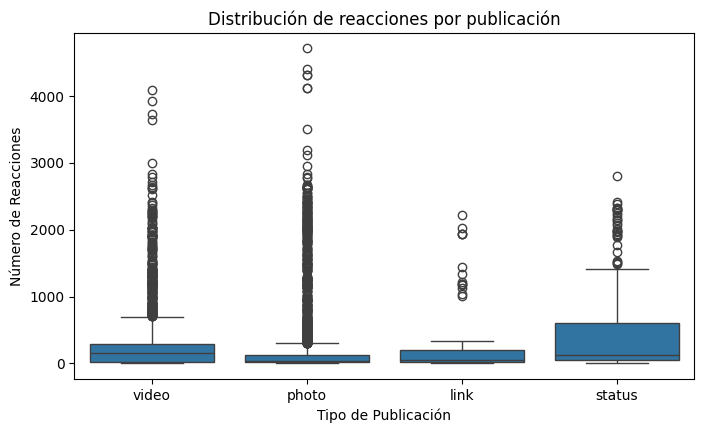

In [48]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df_clean, x="status_type", y="num_reactions")
plt.title("Distribución de reacciones por publicación")
plt.xlabel("Tipo de publicación")
plt.ylabel("Número de reacciones")
plt.show()

Como deciamos y en pocas palabras, gran parte de las reacciones en los tipos de publicaciones de mayor popularidad recaen en los outlines de distribución

# Mapa de calor

Ahora haré un mapa de calor para medir la relacion entre las diferentes reacciones y las fechas de publicación de mi dataframe con el método *corr()*

In [51]:
corr = df_clean[["status_published", "num_reactions", "num_comments", "num_shares", "num_likes", "num_loves", "num_wows", "num_hahas", "num_sads", "num_angrys"]].corr()
corr

,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
status_published,1.000000,-0.054879,0.134403,0.188112,-0.077442,0.199696,0.094868,0.108127,0.069009,0.097191
num_reactions,-0.054879,1.000000,0.150843,0.250723,0.994923,0.305003,0.267752,0.176028,0.075138,0.124326
num_comments,0.134403,0.150843,1.000000,0.640637,0.101687,0.521223,0.162394,0.325048,0.236453,0.225184
num_shares,0.188112,0.250723,0.640637,1.000000,0.172492,0.820000,0.407628,0.399826,0.199970,0.312513
num_likes,-0.077442,0.994923,0.101687,0.172492,1.000000,0.209308,0.207800,0.120784,0.052169,0.087431
num_loves,0.199696,0.305003,0.521223,0.820000,0.209308,1.000000,0.508798,0.507830,0.207600,0.371001
num_wows,0.094868,0.267752,0.162394,0.407628,0.207800,0.508798,1.000000,0.287756,0.086503,0.183087
num_hahas,0.108127,0.176028,0.325048,0.399826,0.120784,0.507830,0.287756,1.000000,0.141421,0.211910
num_sads,0.069009,0.075138,0.236453,0.199970,0.052169,0.207600,0.086503,0.141421,1.000000,0.142072
num_angrys,0.097191,0.124326,0.225184,0.312513,0.087431,0.371001,0.183087,0.211910,0.142072,1.000000


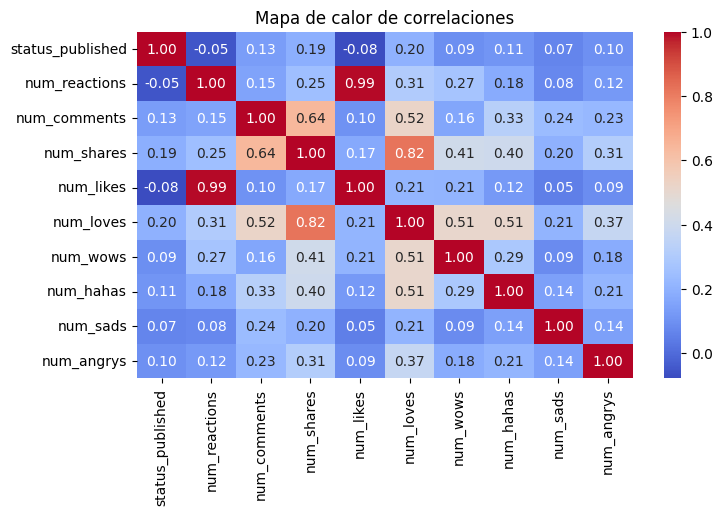

In [52]:
plt.figure(figsize=(8,4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

Con este mapa de calor podemos decir:

1. Hay una correlación de casi 1 entre número de likes y de reacicones por lo que indica que entre más reacciones haya es casi seguro que sean likes frente a otras reacciones

2. Hay una correlación media entre compartidos y me encantas con numero de comentarios, por lo que es medianamente probable que si una publicación tiene comentarios también tenga compartidos o me encanta y viceversa

3. Por otro lado hay una correlación alta de compartidos y me encanta por lo que es muy probable que una publicación con me encanta también sea compartida y viceversa

4. También es medianamente probable que si una publicación tiene me encanta también tenga me divierte o me asombra y viceversa

5. Lo que si tienen una correlación ligeramente negativa son el número de reacciones y numero de likes con respecto a la fecha de publicación, lo cuál tiene sentido, si una publicación es más nueva tendrá menos likes o reacciones, lo cual también sugiere no hay tantos usuarios han interactuado aún

Por otro lado los demás datos entre sí tienen una correlación debil por lo que no indican mucho

## Referencias.

1. GeeksforGeeks. (2025a, julio 11). How to drop one or multiple columns in Pandas DataFrame. GeeksforGeeks. https://www.geeksforgeeks.org/python/how-to-drop-one-or-multiple-columns-in-pandas-dataframe/

2. Pandas - Converting date column from dd/mm/yy hh:mm:ss to yyyy-mm-dd hh:mm:ss. (2018, 7 agosto). Stack Overflow. https://stackoverflow.com/questions/51724883/pandas-converting-date-column-from-dd-mm-yy-hhmmss-to-yyyy-mm-dd-hhmmss
